In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import scipy.sparse as sp


In [2]:
adata= sc.read_h5ad('all_kinetics_adata.h5ad')

In [3]:
mito_genes = adata.var_names.str.startswith('mt-')
ribo_genes = adata.var_names.str.contains('^Rp[sl]')
adata = adata[:, ~(mito_genes | ribo_genes)].copy()

## TAM    

In [4]:
adata_tam = adata[adata.obs['celltype1']=='Macrophage',:].copy()

In [5]:
# calc alpha_tam_gene
alpha_mat = adata_tam.layers['alpha']
alpha_mat[alpha_mat < 0] = np.nan 
if sp.issparse(alpha_mat):
    alpha_dense = alpha_mat.toarray()
    mean_alpha = np.nanmean(alpha_dense, axis=0)
else:
    mean_alpha = np.nanmean(alpha_mat, axis=0)
adata_tam.var['alpha_gene'] = mean_alpha

# calc gamma_tam_gene
gamma_mat = adata_tam.layers['gamma']
gamma_mat[gamma_mat < 0] = np.nan 
if sp.issparse(gamma_mat):
    gamma_dense = gamma_mat.toarray()
    mean_gamma = np.nanmean(gamma_dense, axis=0)
else:
    mean_gamma = np.nanmean(gamma_mat, axis=0)
adata_tam.var['gamma_gene'] = mean_gamma

In [6]:
# 1.filter
gene_df = adata_tam.var[['alpha_gene', 'gamma_gene']].copy()
gene_df = gene_df[(gene_df['alpha_gene'] > 0.1) & 
                  (gene_df['gamma_gene'] > 0) & 
                  (gene_df['gamma_gene'] < 3.07)]

# 2. Z-score
alpha_log = np.log10(gene_df['alpha_gene'])
gene_df['alpha_z'] = (alpha_log - alpha_log.mean()) / alpha_log.std()
gamma_raw =np.log10(gene_df['gamma_gene'])
gene_df['gamma_z'] = (gamma_raw - gamma_raw.mean()) / gamma_raw.std()

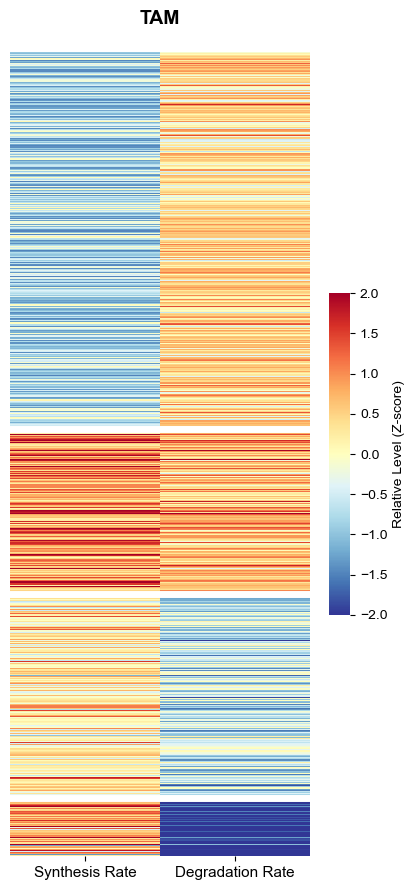

In [7]:
# 3. K-Means
n_clusters = 4 
features = gene_df[['alpha_z', 'gamma_z']].values
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
gene_df['Cluster_ID'] = kmeans.fit_predict(features)

gene_df['Cluster'] = 'Cluster ' + gene_df['Cluster_ID'].astype(str)
custom_order = ['Cluster 1', 'Cluster 3', 'Cluster 0','Cluster 2', ]
gene_df['Cluster'] = pd.Categorical(gene_df['Cluster'], categories=custom_order, ordered=True)
gene_df['gene_name'] = gene_df.index
gene_df = gene_df.sort_values(by=['Cluster']).reset_index(drop=True)
heatmap_data = gene_df[['alpha_z', 'gamma_z']].copy()
heatmap_data.columns = ['Synthesis Rate', 'Degradation Rate']

# 4. heatmap
fig, ax = plt.subplots(figsize=(6, 9))

sns.heatmap(
    heatmap_data, 
    cmap='RdYlBu_r', 
    center=0, 
    vmin=-2, vmax=2,
    cbar_kws={'label': 'Relative Level (Z-score)', 'shrink': 0.4, 'aspect': 15},
    yticklabels=False, 
    ax=ax,
    rasterized=True 
)

cluster_counts = gene_df['Cluster'].value_counts().sort_index()
current_idx = 0

for cluster_name, count in cluster_counts.items():
    next_idx = current_idx + count
    if current_idx > 0:
        ax.axhline(current_idx, color='white', linewidth=5, zorder=10)
    
    current_idx = next_idx
ax.set_title('TAM', fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='x', labelsize=11, rotation=0)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.subplots_adjust(right=0.65) 
plt.savefig('SI_TAM_heatmap_cluster4.pdf', bbox_inches='tight', dpi=300)
plt.show()

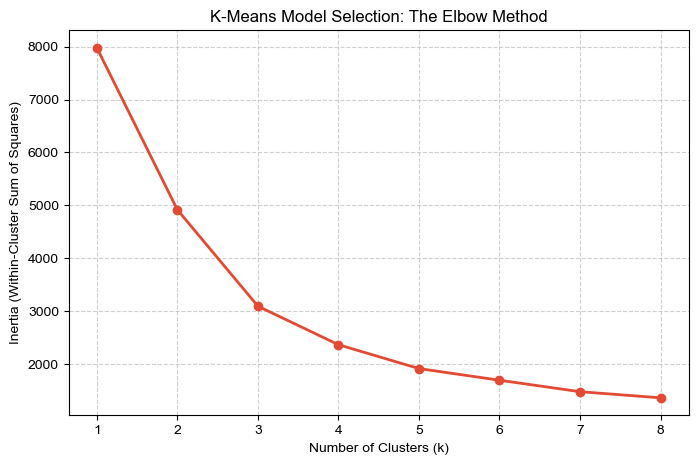

In [8]:
# 
features = gene_df[['alpha_z', 'gamma_z']].values
n_components_range = range(1, 9)
inertia_scores = []

for n in n_components_range:
    kmeans = KMeans(n_clusters=n, random_state=42, n_init='auto')
    kmeans.fit(features)
    inertia_scores.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(n_components_range, inertia_scores, marker='o', color='#E24A33', linewidth=2)
plt.title('K-Means Model Selection: The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(n_components_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('SI_TAM_K-means.pdf', bbox_inches='tight', dpi=300)
plt.show()


 Alpha Top 5
      alpha_gene  gamma_gene
2411   35.101642    1.004763
2419   25.049050    1.492555
2371   17.355532    0.703200
2355   16.430381    0.709327
2358   13.049831    0.519622

 Gamma Top 5
      gamma_gene  alpha_gene
2419    1.492555   25.049050
2411    1.004763   35.101642
2289    0.947118    3.173628
2465    0.919278    4.291869
2022    0.908054    4.162439

 total gene : 8 



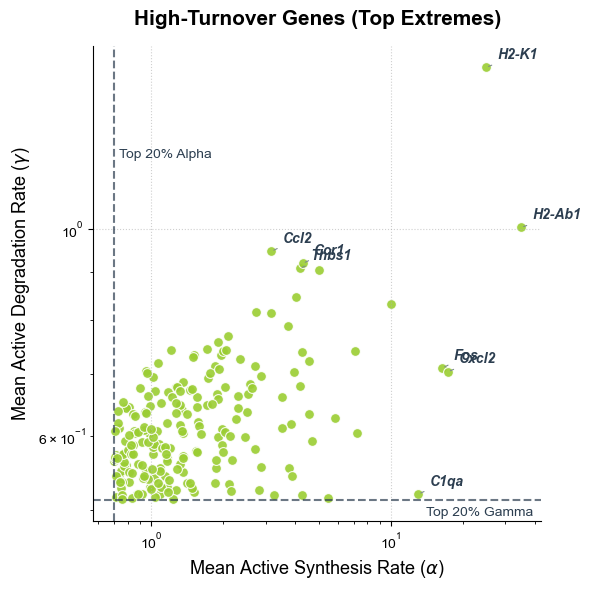

In [9]:

# 1. calc Top 20% 
alpha_threshold = gene_df['alpha_gene'].quantile(0.80)
gamma_threshold = gene_df['gamma_gene'].quantile(0.80)

top20_df = gene_df[(gene_df['alpha_gene'] >= alpha_threshold) & 
                   (gene_df['gamma_gene'] >= gamma_threshold)].copy()

top5_alpha = top20_df.sort_values(by='alpha_gene', ascending=False).head(5)
print("\n Alpha Top 5")
print(top5_alpha[['alpha_gene', 'gamma_gene']])

top5_gamma = top20_df.sort_values(by='gamma_gene', ascending=False).head(5)
print("\n Gamma Top 5")
print(top5_gamma[['gamma_gene','alpha_gene' ]])

top_genes_combined = pd.concat([top5_alpha, top5_gamma]).drop_duplicates()
print(f"\n total gene : {len(top_genes_combined)} \n")


# 2. scatterplot
plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=top20_df, 
    x='alpha_gene', 
    y='gamma_gene',
    color='#9ACD32',     
    alpha=0.9,           
    s=50,                
    edgecolor='white',   
    linewidth=0.8
)

plt.axvline(x=alpha_threshold, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(y=gamma_threshold, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.7)

plt.text(alpha_threshold * 1.05, top20_df['gamma_gene'].max() * 0.8, 
         f"Top 20% Alpha", color='#2c3e50', fontsize=10)
plt.text(top20_df['alpha_gene'].max() * 0.4, gamma_threshold * 0.96, 
         f"Top 20% Gamma", color='#2c3e50', fontsize=10)

for gene_name, row in top_genes_combined.iterrows():
    plt.annotate(
        row['gene_name'],
        (row['alpha_gene'], row['gamma_gene']),
        textcoords="offset points", 
        xytext=(8, 6),      
        ha='left',           
        fontsize=10,
        fontweight='bold',
        fontstyle='italic',  
        color='#2c3e50',
        arrowprops=dict(arrowstyle='-', color='#7f8c8d', lw=0.8) 
    )

plt.title("High-Turnover Genes (Top Extremes)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Mean Active Synthesis Rate ($\\alpha$)", fontsize=13)
plt.ylabel("Mean Active Degradation Rate ($\\gamma$)", fontsize=13)

plt.grid(True, linestyle=':', alpha=0.6)
sns.despine()
plt.xscale('log')
plt.yscale('log')
plt.savefig('final_TAM_top20p_scatter.pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

## PCT    

In [10]:
adata_PCT = adata[adata.obs['celltype1']=='PCT',:].copy()

In [11]:
# calc alpha_tam_gene
alpha_pct = adata_PCT.layers['alpha']
alpha_pct[alpha_pct < 0] = np.nan 
if sp.issparse(alpha_pct):
    alpha_dense = alpha_pct.toarray()
    mean_alpha = np.nanmean(alpha_dense, axis=0)
else:
    mean_alpha = np.nanmean(alpha_pct, axis=0)
adata_PCT.var['alpha_gene'] = mean_alpha

# calc gamma_tam_gene
gamma_pct = adata_PCT.layers['gamma']
gamma_pct[gamma_pct < 0] = np.nan 
if sp.issparse(gamma_pct):
    gamma_dense = gamma_pct.toarray()
    mean_gamma = np.nanmean(gamma_dense, axis=0)
else:
    mean_gamma = np.nanmean(gamma_pct, axis=0)
adata_PCT.var['gamma_gene'] = mean_gamma

/tmp/ipykernel_5465/3346017624.py:18: RuntimeWarning: Mean of empty slice
  mean_gamma = np.nanmean(gamma_pct, axis=0)


In [12]:
# 1.filter
gene_df = adata_PCT.var[['alpha_gene', 'gamma_gene']].copy()
gene_df = gene_df[(gene_df['alpha_gene'] > 0.1) & 
                  (gene_df['gamma_gene'] > 0) & 
                  (gene_df['gamma_gene'] < 3.07)]

# 2. Z-score
alpha_log = np.log10(gene_df['alpha_gene'])
gene_df['alpha_z'] = (alpha_log - alpha_log.mean()) / alpha_log.std()
gamma_raw =np.log10(gene_df['gamma_gene'])
gene_df['gamma_z'] = (gamma_raw - gamma_raw.mean()) / gamma_raw.std()

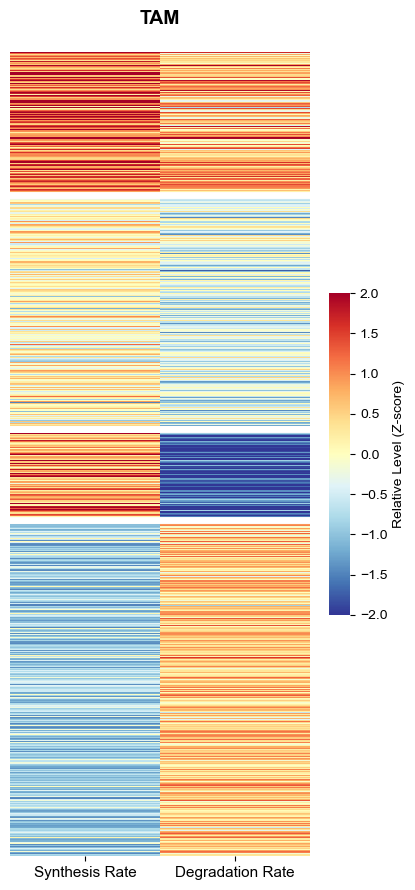

In [13]:
# 3. K-Means
n_clusters = 4 
features = gene_df[['alpha_z', 'gamma_z']].values
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
gene_df['Cluster_ID'] = kmeans.fit_predict(features)

gene_df['Cluster'] = 'Cluster ' + gene_df['Cluster_ID'].astype(str)
custom_order = ['Cluster 1', 'Cluster 3', 'Cluster 0','Cluster 2', ]
gene_df['Cluster'] = pd.Categorical(gene_df['Cluster'], categories=custom_order, ordered=True)
gene_df['gene_name'] = gene_df.index
gene_df = gene_df.sort_values(by=['Cluster']).reset_index(drop=True)
heatmap_data = gene_df[['alpha_z', 'gamma_z']].copy()
heatmap_data.columns = ['Synthesis Rate', 'Degradation Rate']

# 4. heatmap
fig, ax = plt.subplots(figsize=(6, 9))

sns.heatmap(
    heatmap_data, 
    cmap='RdYlBu_r', 
    center=0, 
    vmin=-2, vmax=2,
    cbar_kws={'label': 'Relative Level (Z-score)', 'shrink': 0.4, 'aspect': 15},
    yticklabels=False, 
    ax=ax,
    rasterized=True 
)

cluster_counts = gene_df['Cluster'].value_counts().sort_index()
current_idx = 0

for cluster_name, count in cluster_counts.items():
    next_idx = current_idx + count
    if current_idx > 0:
        ax.axhline(current_idx, color='white', linewidth=5, zorder=10)
    
    current_idx = next_idx
ax.set_title('TAM', fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='x', labelsize=11, rotation=0)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.subplots_adjust(right=0.65) 
plt.savefig('SI_PCT_heatmap_cluster4.pdf', bbox_inches='tight', dpi=300)
plt.show()

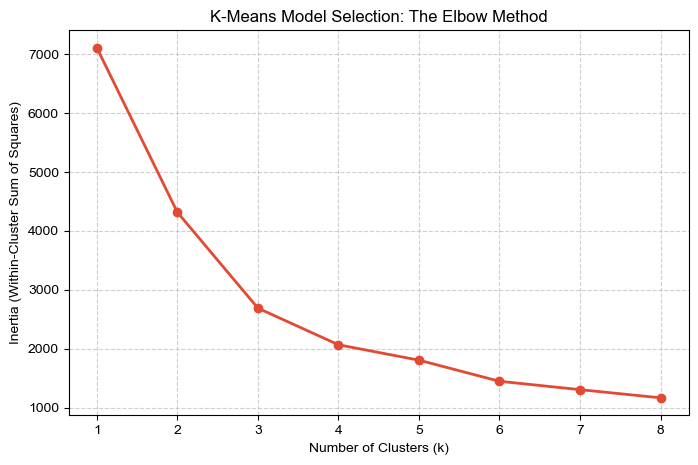

In [14]:
# 
features = gene_df[['alpha_z', 'gamma_z']].values
n_components_range = range(1, 9)
inertia_scores = []

for n in n_components_range:
    kmeans = KMeans(n_clusters=n, random_state=42, n_init='auto')
    kmeans.fit(features)
    inertia_scores.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(n_components_range, inertia_scores, marker='o', color='#E24A33', linewidth=2)
plt.title('K-Means Model Selection: The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(n_components_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('SI_PCT_K-means.pdf', bbox_inches='tight', dpi=300)
plt.show()


 Alpha Top 5
     alpha_gene  gamma_gene
295   18.385765    0.955102
373   17.370652    0.952832
461    6.724172    0.802737
39     5.758723    1.090755
344    5.748661    0.808061

 Gamma Top 5
     gamma_gene  alpha_gene
598    1.235237    5.301928
368    1.202296    3.035535
306    1.142886    4.736924
39     1.090755    5.758723
60     1.045106    1.771647

 total gene : 9 



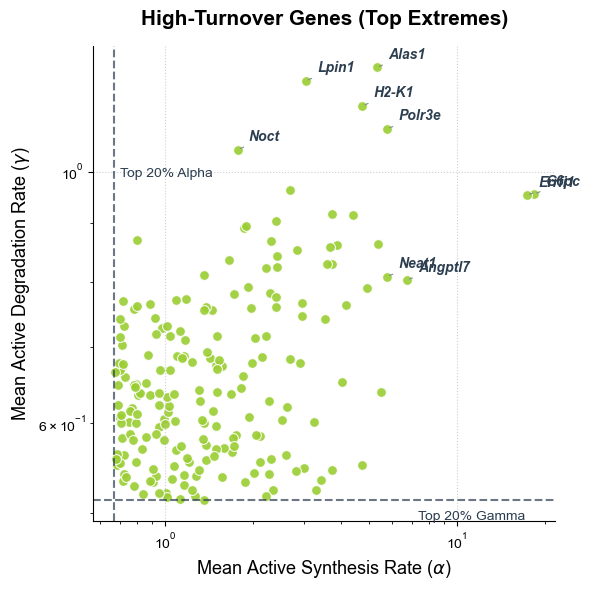

In [15]:

# 1. calc Top 20% 
alpha_threshold = gene_df['alpha_gene'].quantile(0.80)
gamma_threshold = gene_df['gamma_gene'].quantile(0.80)

top20_df = gene_df[(gene_df['alpha_gene'] >= alpha_threshold) & 
                   (gene_df['gamma_gene'] >= gamma_threshold)].copy()

top5_alpha = top20_df.sort_values(by='alpha_gene', ascending=False).head(5)
print("\n Alpha Top 5")
print(top5_alpha[['alpha_gene', 'gamma_gene']])

top5_gamma = top20_df.sort_values(by='gamma_gene', ascending=False).head(5)
print("\n Gamma Top 5")
print(top5_gamma[['gamma_gene','alpha_gene' ]])

top_genes_combined = pd.concat([top5_alpha, top5_gamma]).drop_duplicates()
print(f"\n total gene : {len(top_genes_combined)} \n")


# 2. scatterplot
plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=top20_df, 
    x='alpha_gene', 
    y='gamma_gene',
    color='#9ACD32',     
    alpha=0.9,           
    s=50,                
    edgecolor='white',   
    linewidth=0.8
)

plt.axvline(x=alpha_threshold, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(y=gamma_threshold, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.7)

plt.text(alpha_threshold * 1.05, top20_df['gamma_gene'].max() * 0.8, 
         f"Top 20% Alpha", color='#2c3e50', fontsize=10)
plt.text(top20_df['alpha_gene'].max() * 0.4, gamma_threshold * 0.96, 
         f"Top 20% Gamma", color='#2c3e50', fontsize=10)

for gene_name, row in top_genes_combined.iterrows():
    plt.annotate(
        row['gene_name'],
        (row['alpha_gene'], row['gamma_gene']),
        textcoords="offset points", 
        xytext=(8, 6),      
        ha='left',           
        fontsize=10,
        fontweight='bold',
        fontstyle='italic',  
        color='#2c3e50',
        arrowprops=dict(arrowstyle='-', color='#7f8c8d', lw=0.8) 
    )

plt.title("High-Turnover Genes (Top Extremes)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Mean Active Synthesis Rate ($\\alpha$)", fontsize=13)
plt.ylabel("Mean Active Degradation Rate ($\\gamma$)", fontsize=13)

plt.grid(True, linestyle=':', alpha=0.6)
sns.despine()
plt.xscale('log')
plt.yscale('log')
plt.savefig('final_PCT_top20p_scatter.pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()